In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score


In [2]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [5]:
print(df.head())   
  

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
print(df.tail()) 

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8


In [6]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


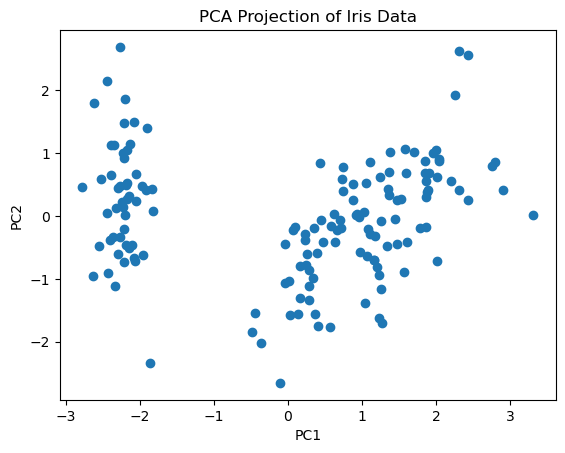

In [7]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection of Iris Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


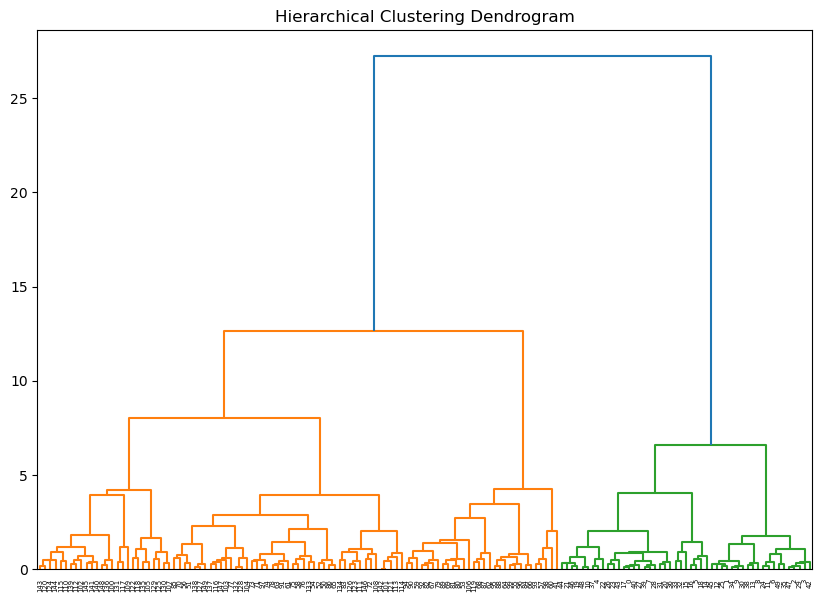

In [8]:
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()


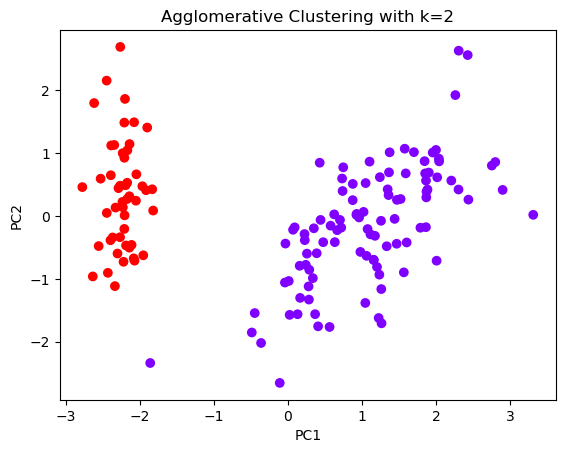

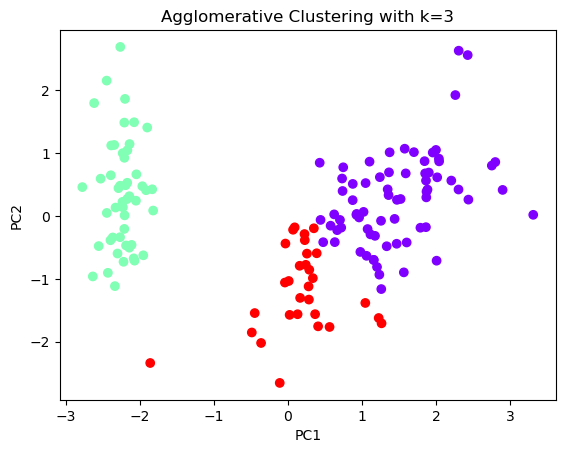

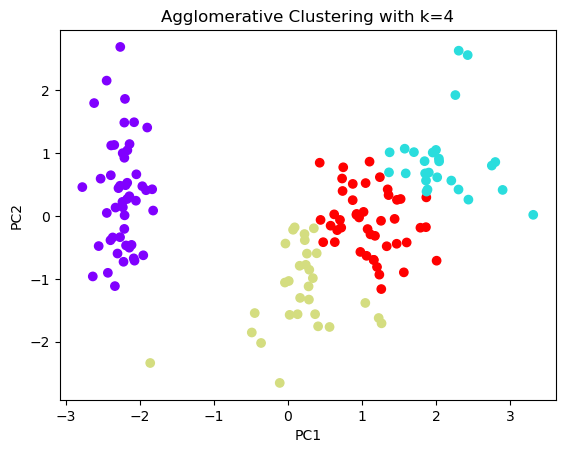

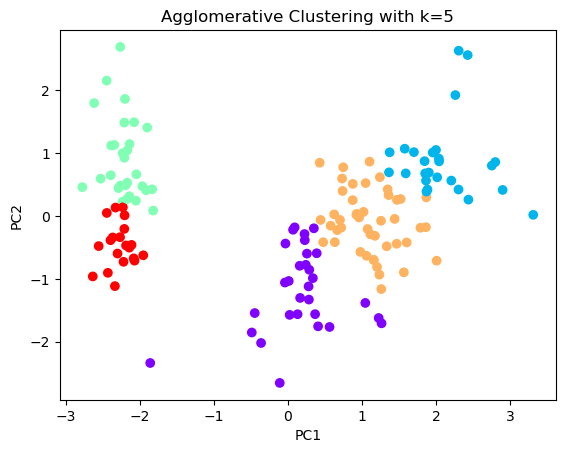

In [9]:
for k in [2, 3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='rainbow')
    plt.title(f"Agglomerative Clustering with k={k}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()


In [10]:
for k in [2, 3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score for k={k}: {score:.3f}")


Silhouette Score for k=2: 0.577
Silhouette Score for k=3: 0.447
Silhouette Score for k=4: 0.401
Silhouette Score for k=5: 0.331
